## Meta Platforms Inc. (FB) — Technical Analysis

### Overview
This notebook performs technical analysis on **Meta Platforms Inc. (FB)** stock price data using industry-standard indicators. The analysis covers moving averages, Bollinger Bands, momentum indicators, volatility metrics, time series decomposition, and stationarity analysis.

### Objectives
- Load and validate FB historical stock price data
- Compute technical indicators using TA-Lib and PyNance
- Visualize price trends with overlaid technical indicators
- Analyze momentum, volatility, and time series properties
- Compute quantitative performance metrics

### Dataset
The analysis uses historical FB stock price data containing Open, High, Low, Close, and Volume (OHLCV) data.

### Understanding Stock Market Data
Before diving into analysis, let's define the standard columns in our dataset:

- **Open:** The price at the start of the trading day
- **High:** The maximum price reached during the day
- **Low:** The minimum price reached during the day
- **Close:** The final price when the market closed — primary price for technical indicators
- **Volume:** The total number of shares traded during the period

## 1. Environment Setup & Library Imports

In [1]:
# Fix PyNance compatibility with modern pandas_datareader
import pandas.util._decorators as _dec

def _patched_deprecate_kwarg(*args, **kwargs):
    if len(args) == 2 and isinstance(args[0], str):
        return _original_deprecate_kwarg(FutureWarning, args[0], args[1], **kwargs)
    return _original_deprecate_kwarg(*args, **kwargs)

if not hasattr(_dec, '_original_deprecate_kwarg'):
    _original_deprecate_kwarg = _dec.deprecate_kwarg
    _dec.deprecate_kwarg = _patched_deprecate_kwarg

import pynance as pn
print("✅ PyNance imported successfully!")

✅ PyNance imported successfully!


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock_data
from src.analysis import (
    compute_sma,
    compute_ema,
    compute_rsi,
    compute_macd,
    compute_bollinger_bands,
    get_daily_return,
    check_stationarity
)

# Global plot settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"TA-Lib version : {talib.__version__}")
print("✅ All libraries imported successfully!")

TA-Lib version : 0.6.8
✅ All libraries imported successfully!


## 2. Load & Clean Stock Price Data

We load the FB historical stock price dataset using our modular `load_stock_data()` function from `src/data_loader.py`. This enforces correct data types, sorts by date, and handles missing values automatically.

In [4]:
fb = load_stock_data('../data/raw/META.csv')

print(f"Dataset Shape: {fb.shape}")
print(f"\nColumn Names: {fb.columns.tolist()}")
print(f"\nDate range: {fb['Date'].min().date()} to {fb['Date'].max().date()}")
print(f"Total trading days: {len(fb)}")
fb.head()

✅ Loaded 2923 rows. No missing values.
Dataset Shape: (2923, 6)

Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2012-05-18 to 2023-12-29
Total trading days: 2923


,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400.0
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700.0
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600.0
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000.0
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200.0


## 3. Moving Averages (SMA & EMA)

Moving averages smooth out price data to identify trends:
- **SMA (Simple Moving Average)** — equal weight to all periods
- **EMA (Exponential Moving Average)** — more weight to recent prices

**Interpretation:**
- **Golden Cross:** Short-term MA crosses above long-term MA → bullish signal
- **Death Cross:** Short-term MA crosses below long-term MA → bearish signal

In [5]:
fb['SMA_20'] = compute_sma(fb['Close'], 20)
fb['SMA_50'] = compute_sma(fb['Close'], 50)
fb['EMA_20'] = compute_ema(fb['Close'], 20)
fb['EMA_50'] = compute_ema(fb['Close'], 50)

print("✅ Moving averages computed successfully!")
print(fb[['Date', 'Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail(10))

✅ Moving averages computed successfully!
           Date       Close      SMA_20      SMA_50      EMA_20      EMA_50
2913 2023-12-15  332.867981  329.319841  320.452905  327.117185  320.350016
2914 2023-12-18  342.508514  329.795905  321.033127  328.583026  321.218976
2915 2023-12-19  348.213318  330.312218  321.669206  330.452578  322.277578
2916 2023-12-20  347.139984  330.923450  322.214644  332.041854  323.252574
2917 2023-12-21  351.920502  331.549590  322.736824  333.935059  324.376807
2918 2023-12-22  351.224823  332.302945  323.317843  335.581703  325.429670
2919 2023-12-26  352.655975  333.303278  324.115724  337.207824  326.497368
2920 2023-12-27  355.637543  334.239505  324.844828  338.963036  327.640120
2921 2023-12-28  356.124634  335.537503  325.527023  340.597473  328.757160
2922 2023-12-29  351.791290  336.869788  326.262290  341.663551  329.660459


### 3.1 Moving Averages Visualization

The chart below shows FB closing prices overlaid with 20-day and 50-day SMA and EMA. When the short-term average crosses above the long-term average it signals a potential **buy opportunity**, and vice versa.

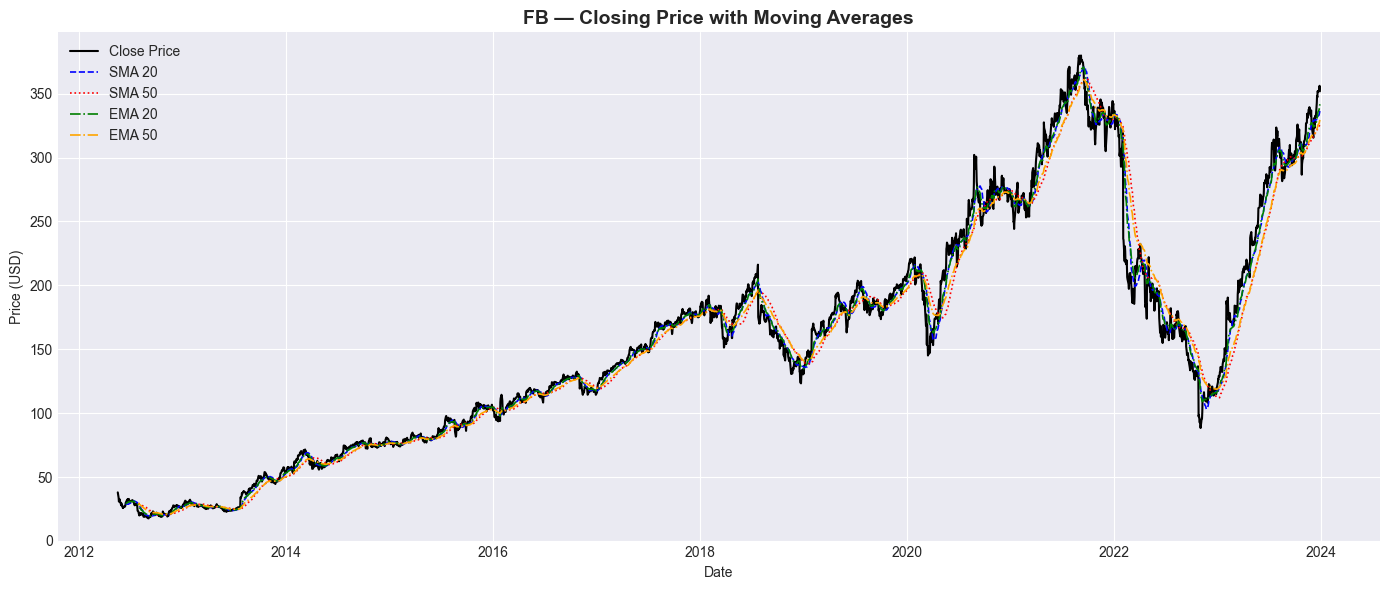

✅ Moving averages plot rendered!


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(fb['Date'], fb['Close'], label='Close Price', color='black', linewidth=1.5)
ax.plot(fb['Date'], fb['SMA_20'], label='SMA 20', color='blue', linewidth=1.2, linestyle='--')
ax.plot(fb['Date'], fb['SMA_50'], label='SMA 50', color='red', linewidth=1.2, linestyle=':')
ax.plot(fb['Date'], fb['EMA_20'], label='EMA 20', color='green', linewidth=1.2, linestyle='-.')
ax.plot(fb['Date'], fb['EMA_50'], label='EMA 50', color='orange', linewidth=1.2, linestyle='-.')

ax.set_title('FB — Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Moving averages plot rendered!")

## 4. Bollinger Bands

Bollinger Bands consist of:
- **Middle Band** — 20-day SMA
- **Upper Band** — Middle Band + 2 standard deviations
- **Lower Band** — Middle Band - 2 standard deviations

Price touching the upper band suggests **overbought** conditions while touching the lower band suggests **oversold** conditions.

In [7]:
fb['BB_Upper'], fb['BB_Middle'], fb['BB_Lower'] = compute_bollinger_bands(
    fb['Close'])

print("✅ Bollinger Bands computed successfully!")
print(fb[['Date', 'Close', 'BB_Upper', 'BB_Middle', 'BB_Lower']].tail(10))

✅ Bollinger Bands computed successfully!
           Date       Close    BB_Upper   BB_Middle    BB_Lower
2913 2023-12-15  332.867981  343.303187  329.319841  315.336495
2914 2023-12-18  342.508514  344.853317  329.795905  314.738492
2915 2023-12-19  348.213318  347.057552  330.312218  313.566883
2916 2023-12-20  347.139984  349.125340  330.923450  312.721560
2917 2023-12-21  351.920502  351.638224  331.549590  311.460955
2918 2023-12-22  351.224823  354.085026  332.302945  310.520864
2919 2023-12-26  352.655975  356.825215  333.303278  309.781340
2920 2023-12-27  355.637543  359.674389  334.239505  308.804621
2921 2023-12-28  356.124634  362.605290  335.537503  308.469716
2922 2023-12-29  351.791290  364.379857  336.869788  309.359718


### 4.1 Bollinger Bands Visualization

The shaded region between the upper and lower bands represents the expected price range. Prices outside this range signal potential reversals.

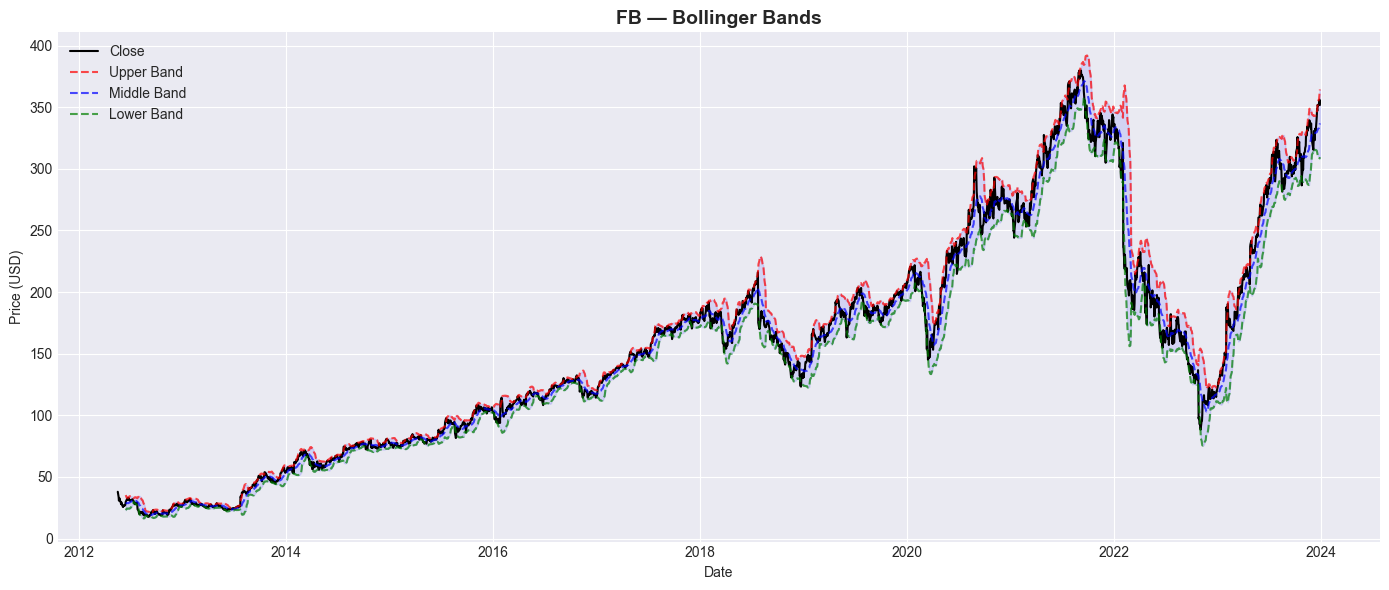

✅ Bollinger Bands plot rendered!


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(fb['Date'], fb['Close'], label='Close', color='black', linewidth=1.5)
ax.plot(fb['Date'], fb['BB_Upper'], label='Upper Band', color='red',
        linestyle='--', alpha=0.7)
ax.plot(fb['Date'], fb['BB_Middle'], label='Middle Band', color='blue',
        linestyle='--', alpha=0.7)
ax.plot(fb['Date'], fb['BB_Lower'], label='Lower Band', color='green',
        linestyle='--', alpha=0.7)
ax.fill_between(fb['Date'], fb['BB_Upper'], fb['BB_Lower'],
                alpha=0.1, color='blue')

ax.set_title('FB — Bollinger Bands', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Bollinger Bands plot rendered!")

## 5. RSI (Relative Strength Index)

RSI is a **momentum oscillator** that measures the speed and change of price movements:
- **RSI >= 70** — Overbought: potential sell signal
- **RSI <= 30** — Oversold: potential buy signal
- **RSI = 50** — Neutral momentum

We use the standard 14-day period.

In [9]:
fb['RSI'] = compute_rsi(fb['Close'])

print("✅ RSI computed successfully!")
print(fb[['Date', 'Close', 'RSI']].tail(10))

✅ RSI computed successfully!
           Date       Close        RSI
2913 2023-12-15  332.867981  56.769317
2914 2023-12-18  342.508514  63.383621
2915 2023-12-19  348.213318  66.636636
2916 2023-12-20  347.139984  65.458340
2917 2023-12-21  351.920502  68.158903
2918 2023-12-22  351.224823  67.333885
2919 2023-12-26  352.655975  68.187000
2920 2023-12-27  355.637543  69.947874
2921 2023-12-28  356.124634  70.237702
2922 2023-12-29  351.791290  64.296803


## 6. MACD (Moving Average Convergence Divergence)

MACD identifies momentum shifts and trend reversals:
- **MACD Line** — difference between 12-day and 26-day EMA
- **Signal Line** — 9-day EMA of the MACD line
- **Histogram** — difference between MACD and Signal line

- **Bullish Crossover:** MACD crosses above Signal → buy signal
- **Bearish Crossover:** MACD crosses below Signal → sell signal
- **Divergence:** Price makes new high but MACD does not → trend weakening

In [10]:
fb['MACD'], fb['MACD_Signal'], fb['MACD_Hist'] = compute_macd(
    fb['Close'])

print("✅ MACD computed successfully!")
print(fb[['Date', 'Close', 'MACD', 'MACD_Signal', 'MACD_Hist']].tail(10))

✅ MACD computed successfully!
           Date       Close      MACD  MACD_Signal  MACD_Hist
2913 2023-12-15  332.867981  2.650382     2.594225   0.056158
2914 2023-12-18  342.508514  3.570449     2.789470   0.780980
2915 2023-12-19  348.213318  4.705695     3.172715   1.532980
2916 2023-12-20  347.139984  5.455884     3.629348   1.826535
2917 2023-12-21  351.920502  6.362815     4.176042   2.186773
2918 2023-12-22  351.224823  6.945367     4.729907   2.215461
2919 2023-12-26  352.655975  7.436800     5.271285   2.165514
2920 2023-12-27  355.637543  7.974921     5.812012   2.162908
2921 2023-12-28  356.124634  8.344500     6.318510   2.025990
2922 2023-12-29  351.791290  8.193282     6.693464   1.499818


### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

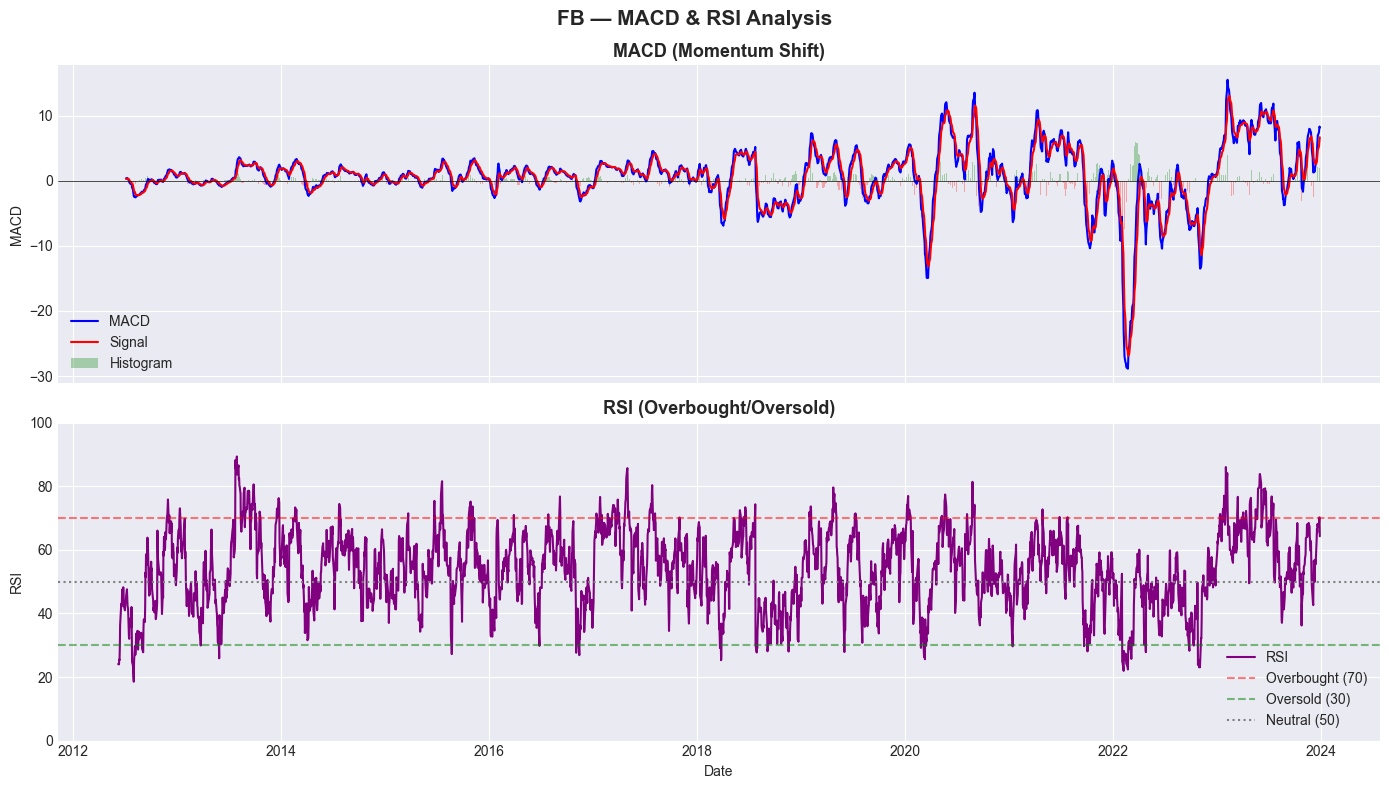

✅ MACD & RSI plot rendered!


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(fb['Date'], fb['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(fb['Date'], fb['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(fb['Date'], fb['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in fb['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(fb['Date'], fb['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('FB — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

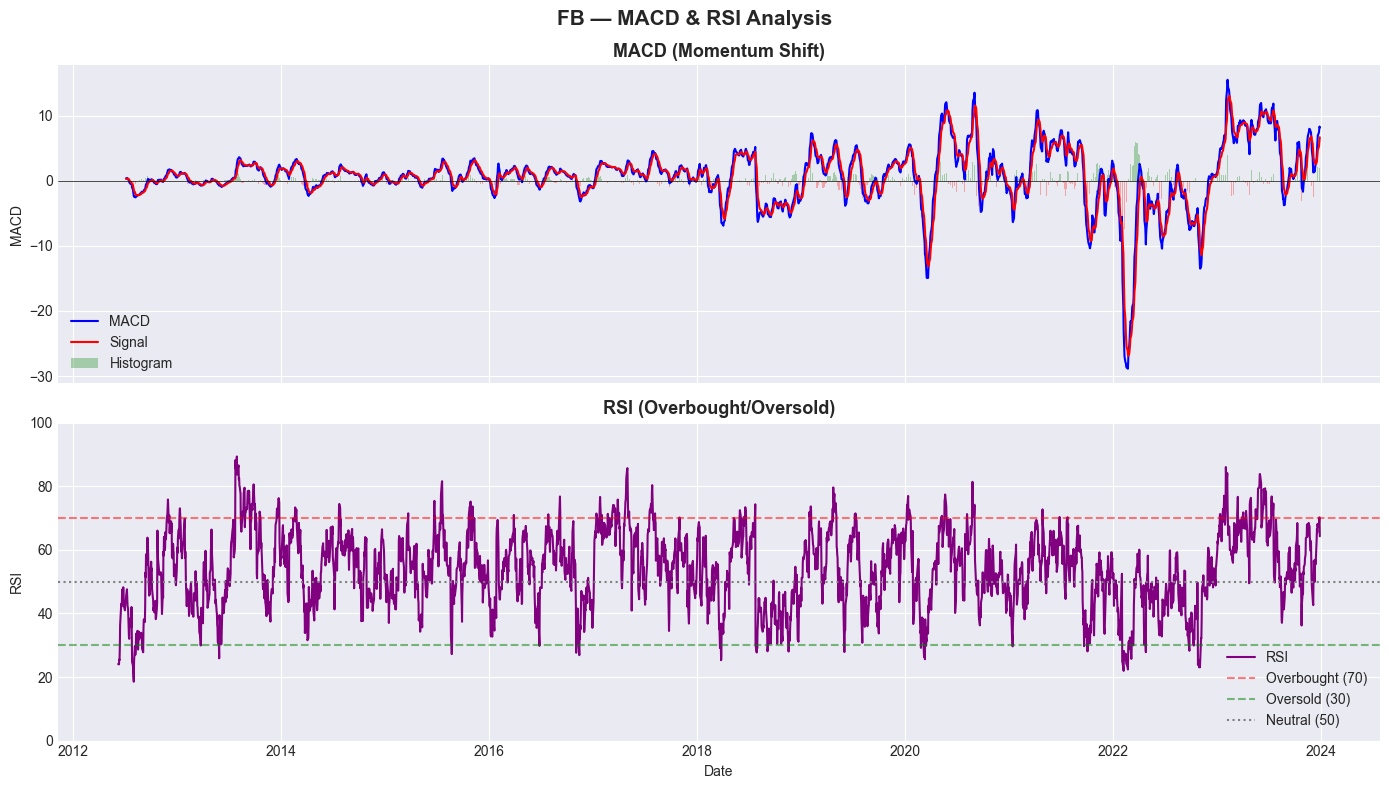

✅ MACD & RSI plot rendered!


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(fb['Date'], fb['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(fb['Date'], fb['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(fb['Date'], fb['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in fb['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(fb['Date'], fb['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('FB — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

## 7. PyNance Technical Indicators

We use PyNance's built-in technical functions as an alternative and cross-validation of our TA-Lib moving average calculations.

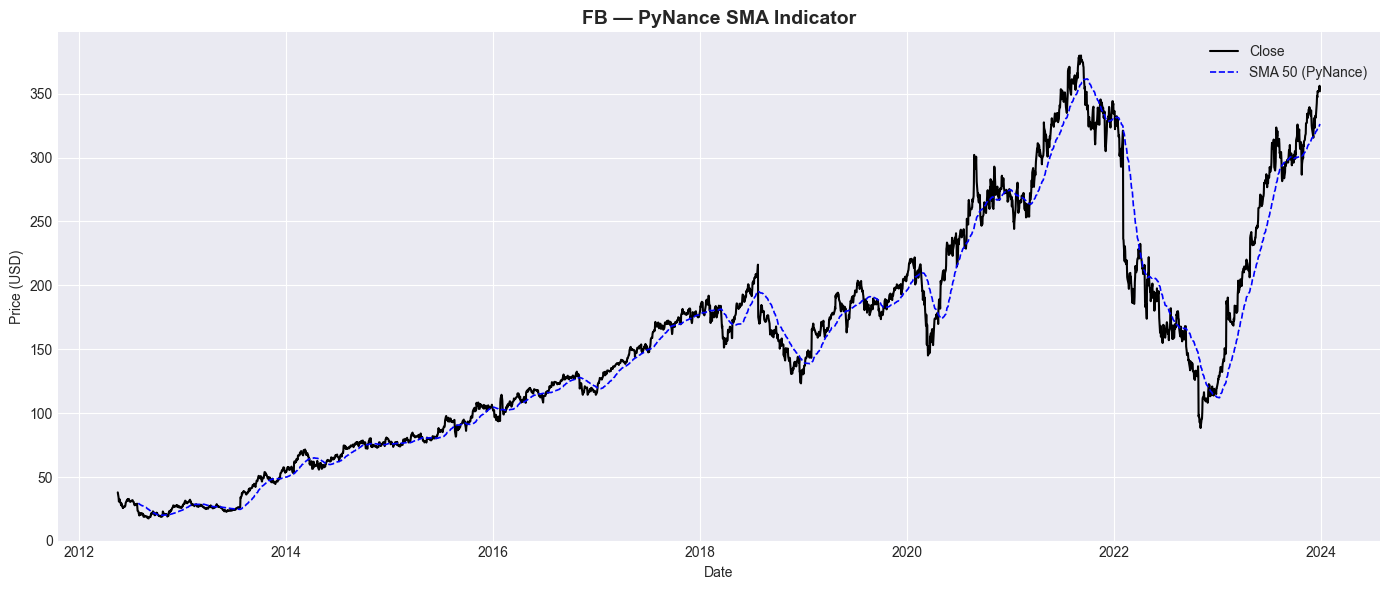

✅ PyNance SMA computed and plotted successfully!


In [13]:
try:
    fb['SMA_50_pn'] = pn.tech.sma(fb['Close'], window=50)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(fb['Date'], fb['Close'], label='Close', color='black', linewidth=1.5)
    ax.plot(fb['Date'], fb['SMA_50_pn'], label='SMA 50 (PyNance)',
            color='blue', linewidth=1.2, linestyle='--')
    ax.set_title('FB — PyNance SMA Indicator', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("✅ PyNance SMA computed and plotted successfully!")
except Exception as e:
    print(f"PyNance error: {e}")

## 8. Daily Returns & Volatility

We compute daily percentage returns and 20-day rolling volatility to understand FB's risk profile during the analysis period.

In [14]:
fb['Returns'] = get_daily_return(fb['Close'])
fb['Volatility_20'] = fb['Returns'].rolling(window=20).std()

print("✅ Daily returns and volatility computed!")
print(f"\nAverage Daily Return : {fb['Returns'].mean():.4f}")
print(f"Daily Return Std Dev : {fb['Returns'].std():.4f}")
print(f"Max Daily Gain       : {fb['Returns'].max():.4f}")
print(f"Max Daily Loss       : {fb['Returns'].min():.4f}")

✅ Daily returns and volatility computed!

Average Daily Return : 0.0011
Daily Return Std Dev : 0.0253
Max Daily Gain       : 0.2961
Max Daily Loss       : -0.2639


### 8.1 Daily Returns & Volatility Visualization

The charts below show FB's daily returns and 20-day rolling volatility, highlighting periods of elevated market uncertainty.

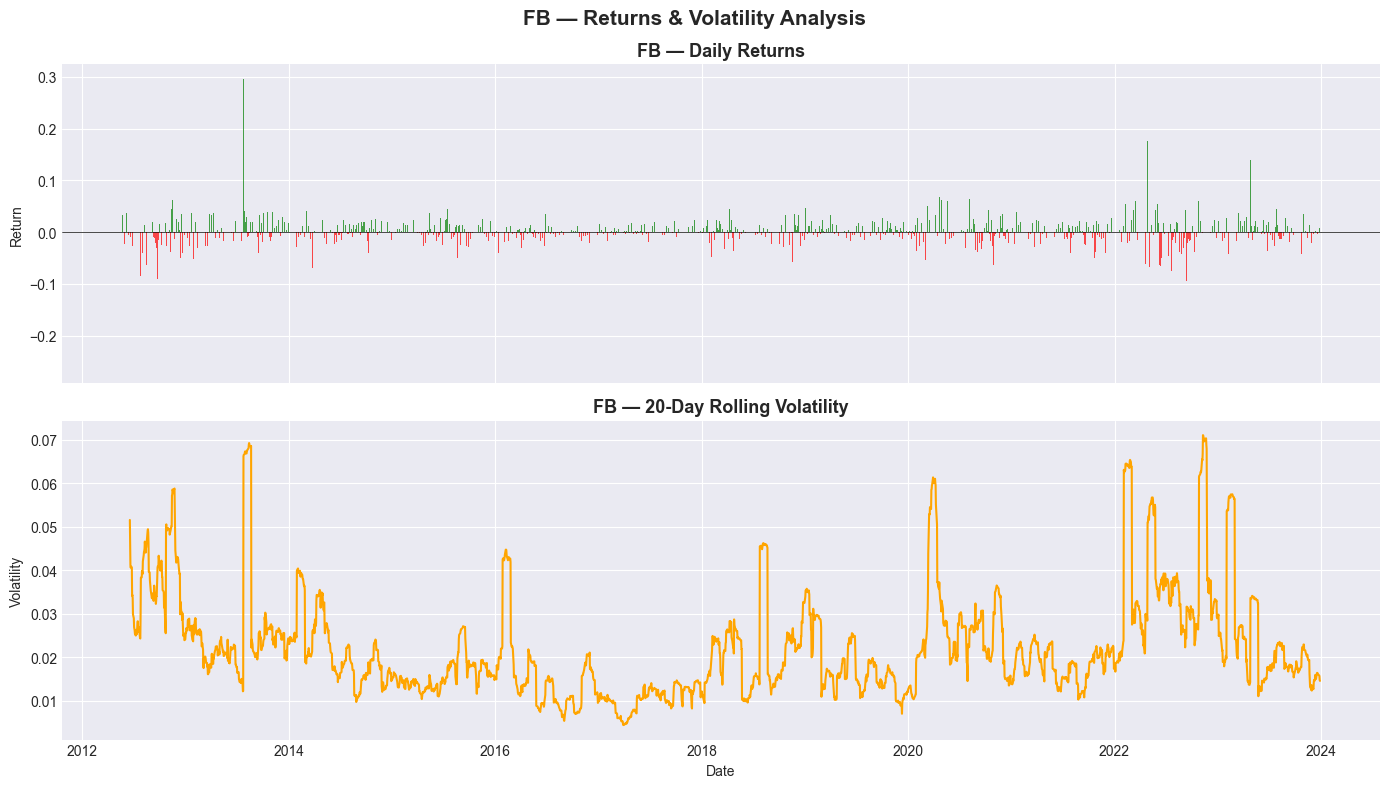

✅ Returns and volatility plot rendered!


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(fb['Date'], fb['Returns'],
            color=['green' if v >= 0 else 'red' for v in fb['Returns'].fillna(0)],
            alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('FB — Daily Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return')

axes[1].plot(fb['Date'], fb['Volatility_20'], color='orange', linewidth=1.5)
axes[1].set_title('FB — 20-Day Rolling Volatility', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.suptitle('FB — Returns & Volatility Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Returns and volatility plot rendered!")

## 9. QuantStats Performance Metrics

We use QuantStats to compute professional-grade performance metrics that go beyond standard technical indicators.

In [16]:
try:
    import quantstats as qs
    qs.extend_pandas()

    returns = fb.set_index('Date')['Close'].pct_change()

    print("=== FB QuantStats Performance Metrics ===")
    print(f"Sharpe Ratio : {qs.stats.sharpe(returns):.2f}")
    print(f"Max Drawdown : {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Volatility   : {qs.stats.volatility(returns)*100:.2f}%")
    print(f"CAGR         : {qs.stats.cagr(returns)*100:.2f}%")
    print("✅ QuantStats metrics computed!")
except Exception as e:
    print(f"QuantStats error: {e}")

=== FB QuantStats Performance Metrics ===
Sharpe Ratio : 0.68
Max Drawdown : -76.74%
Volatility   : 40.12%
CAGR         : 21.15%
✅ QuantStats metrics computed!


## 10. Time Series Decomposition

We decompose the FB closing price into its core components:
- **Trend** — long-term direction of the price
- **Seasonal** — repeating patterns over time
- **Residual** — random noise remaining after removing trend and seasonality

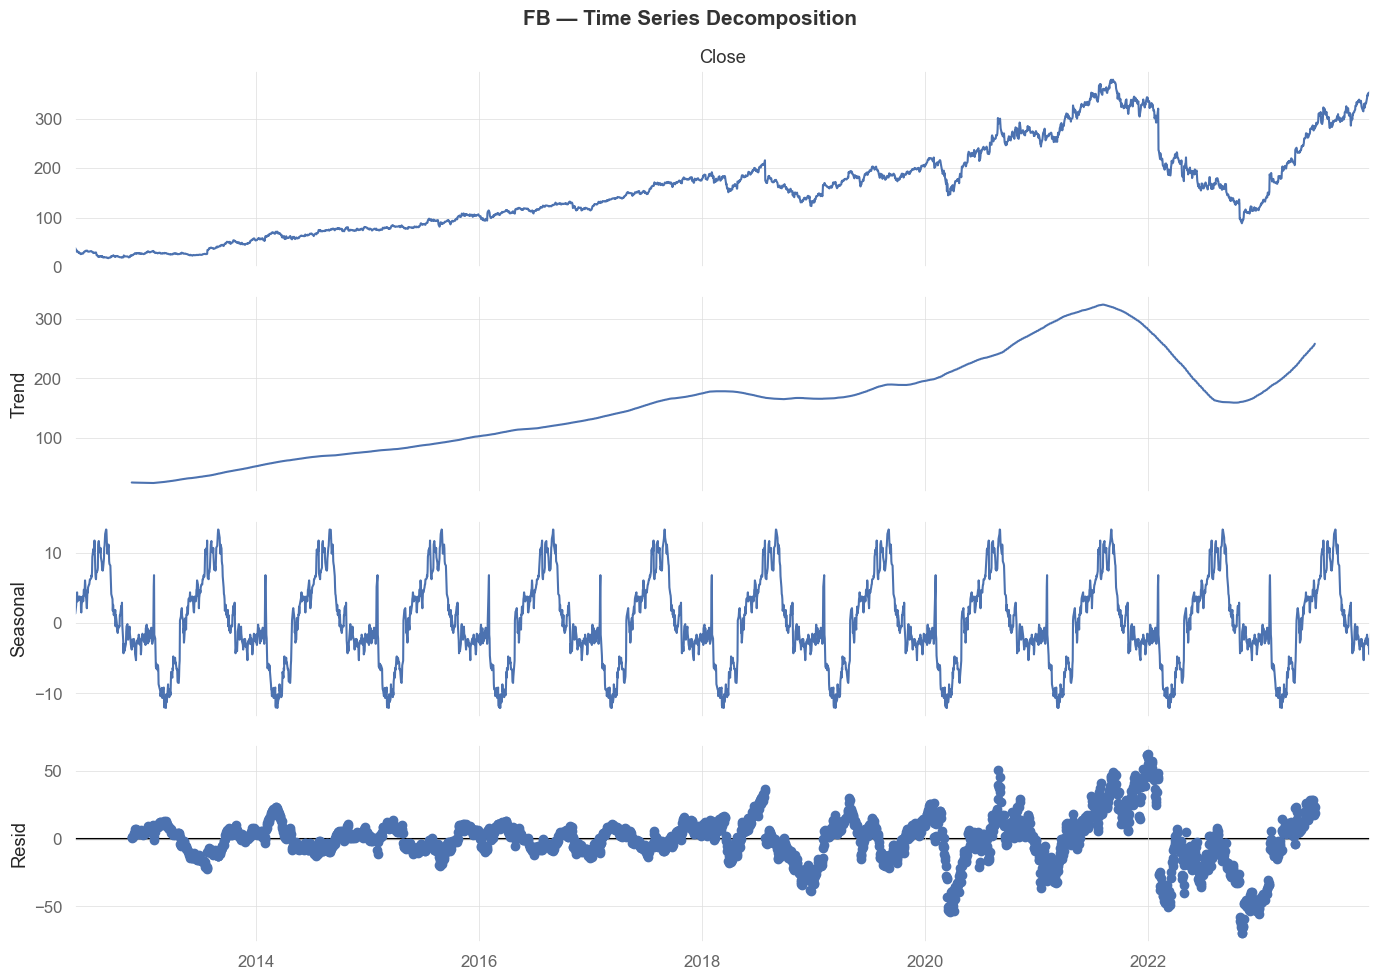

✅ Time series decomposition complete!


In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

fb_ts = fb.set_index('Date')['Close']

result = seasonal_decompose(fb_ts, model='additive', period=252)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle('FB — Time Series Decomposition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series decomposition complete!")

### 10.1 Decomposition Interpretation

The decomposition of FB's closing price reveals the following components:

- **Observed:** FB's price history begins at its May 2012 IPO, showing initial volatility before a sustained upward trajectory through 2021, followed by a sharp crash in 2022 and partial recovery into 2023.
- **Trend:** The trend component shows steady growth from 2013 through 2021, a sharp peak and decline in 2022 — corresponding to Meta's pivot to the metaverse and associated investor skepticism — followed by a recovery into late 2023.
- **Seasonal:** Regular annual cycles are visible, likely tied to quarterly earnings releases and advertising revenue patterns that drive Facebook's business.
- **Residual:** Residuals are relatively contained until 2020, then show sharp spikes particularly around 2022 — reflecting the dramatic price crash driven by regulatory pressure, privacy concerns, and the costly metaverse pivot.

## 11. Stationarity Analysis

A **stationary** time series has constant mean, variance, and covariance over time. Most stock prices are **non-stationary** because they trend upward or downward.

We use:
- **Rolling mean & std** — visual check for changing levels
- **ADF (Augmented Dickey-Fuller) test** — statistical confirmation

**Interpretation:**
- p-value < 0.05 → stationary
- p-value ≥ 0.05 → non-stationary

=== Stationarity Check: Original Price Series ===


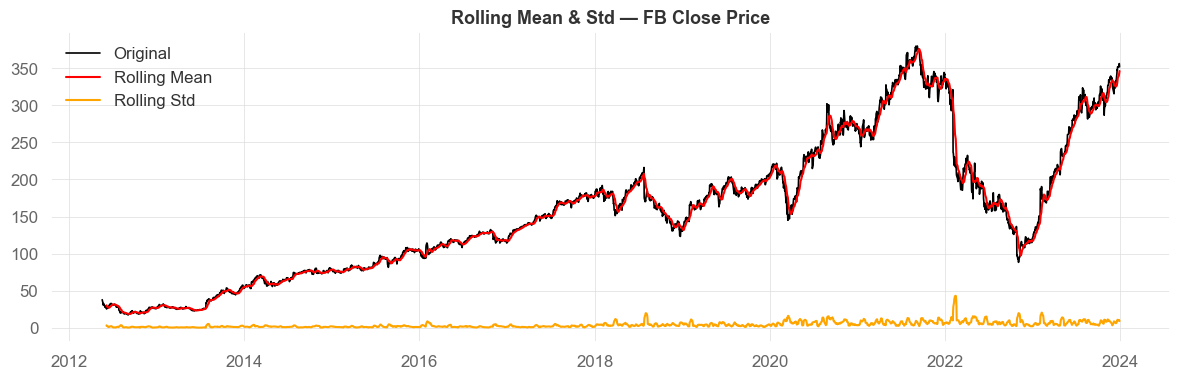

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -0.7629
p-value       : 0.8298
Conclusion: ⚠️  Non-Stationary (Fail to Reject Null Hypothesis)


In [18]:
print("=== Stationarity Check: Original Price Series ===")
check_stationarity(fb_ts, title='FB Close Price')

### 11.1 First-Order Differencing

Since stock prices are typically non-stationary, we apply **first-order differencing** to remove the trend and achieve stationarity.

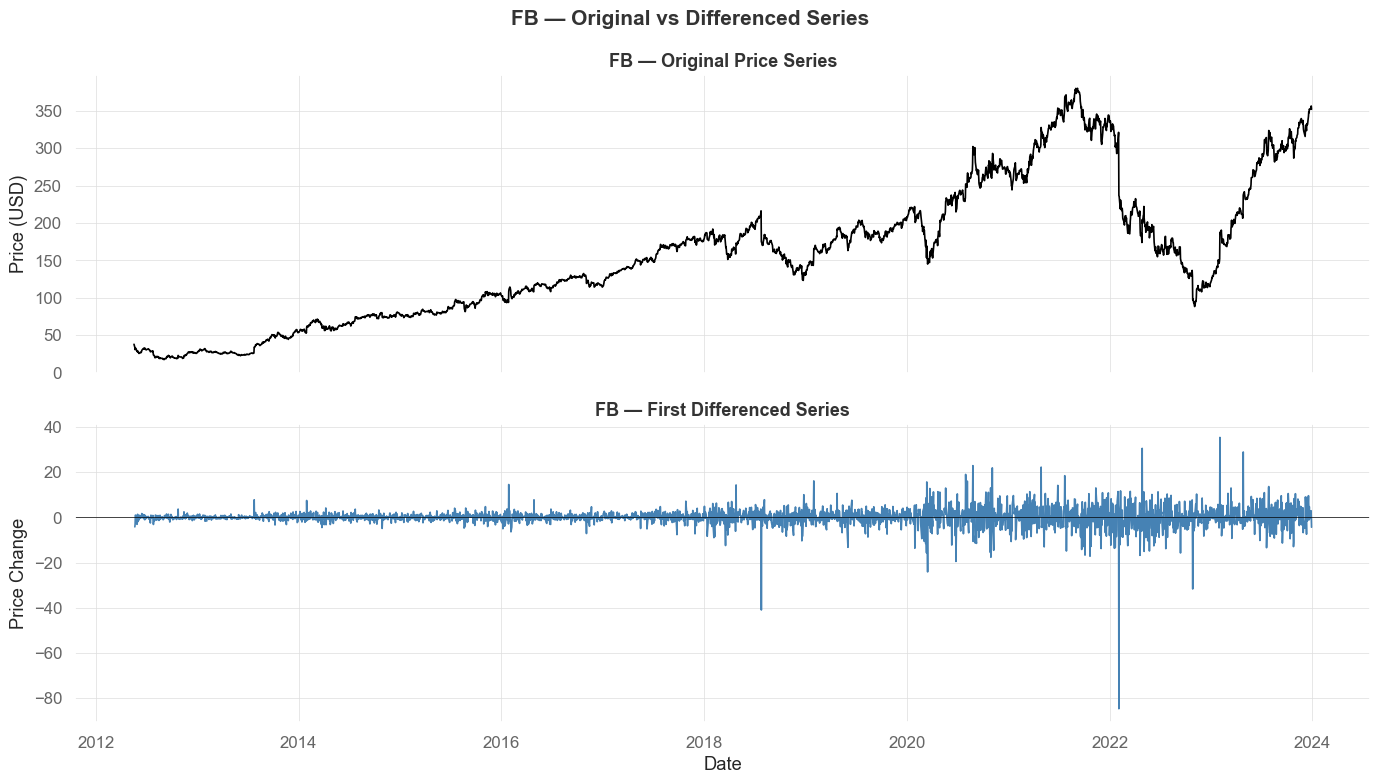


=== Stationarity Check: Differenced Series ===


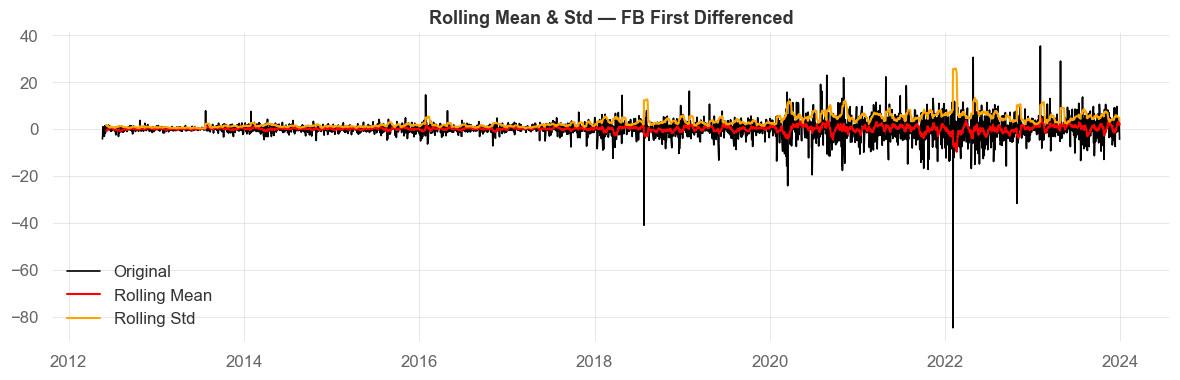

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -10.2105
p-value       : 0.0000
Conclusion: ✅ Stationary (Reject Null Hypothesis)


In [19]:
fb_diff = fb_ts.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(fb_ts, color='black', linewidth=1.2)
axes[0].set_title('FB — Original Price Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(fb_diff, color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('FB — First Differenced Series', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change')
axes[1].set_xlabel('Date')

plt.suptitle('FB — Original vs Differenced Series', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Stationarity Check: Differenced Series ===")
check_stationarity(fb_diff, title='FB First Differenced')

## 12. Key Findings & Summary

In [20]:
print("=" * 55)
print("     FB TECHNICAL ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"""
📈 PRICE OVERVIEW
- Date range        : {fb['Date'].min().date()} to {fb['Date'].max().date()}
- Starting price    : ${fb['Close'].iloc[0]:.2f}
- Ending price      : ${fb['Close'].iloc[-1]:.2f}
- Price change      : {((fb['Close'].iloc[-1] - fb['Close'].iloc[0]) / fb['Close'].iloc[0] * 100):.2f}%

📊 MOVING AVERAGES
- Final SMA 20      : ${fb['SMA_20'].iloc[-1]:.2f}
- Final SMA 50      : ${fb['SMA_50'].iloc[-1]:.2f}
- Final EMA 20      : ${fb['EMA_20'].iloc[-1]:.2f}
- Final EMA 50      : ${fb['EMA_50'].iloc[-1]:.2f}

📐 BOLLINGER BANDS
- BB Upper Band     : ${fb['BB_Upper'].iloc[-1]:.2f}
- BB Middle Band    : ${fb['BB_Middle'].iloc[-1]:.2f}
- BB Lower Band     : ${fb['BB_Lower'].iloc[-1]:.2f}

⚡ MOMENTUM (RSI)
- Final RSI         : {fb['RSI'].iloc[-1]:.2f}
- Average RSI       : {fb['RSI'].mean():.2f}
- Overbought days   : {(fb['RSI'] > 70).sum()}
- Oversold days     : {(fb['RSI'] < 30).sum()}

📉 VOLATILITY & RETURNS
- Avg daily return  : {fb['Returns'].mean():.4f}
- Max daily gain    : {fb['Returns'].max():.4f}
- Max daily loss    : {fb['Returns'].min():.4f}
""")
print("=" * 55)

     FB TECHNICAL ANALYSIS — KEY FINDINGS

📈 PRICE OVERVIEW
- Date range        : 2012-05-18 to 2023-12-29
- Starting price    : $38.00
- Ending price      : $351.79
- Price change      : 825.87%

📊 MOVING AVERAGES
- Final SMA 20      : $336.87
- Final SMA 50      : $326.26
- Final EMA 20      : $341.66
- Final EMA 50      : $329.66

📐 BOLLINGER BANDS
- BB Upper Band     : $364.38
- BB Middle Band    : $336.87
- BB Lower Band     : $309.36

⚡ MOMENTUM (RSI)
- Final RSI         : 64.30
- Average RSI       : 53.81
- Overbought days   : 235
- Oversold days     : 76

📉 VOLATILITY & RETURNS
- Avg daily return  : 0.0011
- Max daily gain    : 0.2961
- Max daily loss    : -0.2639



## 13. Conclusion

The technical analysis of FB stock shows solid growth of **825.87%** since its IPO in May 2012. The stock closed significantly above both its 20-day and 50-day moving averages, confirming a strong **bullish trend** at the end of the analysis period.

The RSI averaged **53.81** — near neutral — with **235 overbought days** and **76 oversold days**. The wide Bollinger Band spread (Upper: $364.38, Lower: $309.36) reflects elevated volatility in the recent period. The extreme maximum daily loss of **-26.39%** reflects the significant price crashes Facebook experienced during regulatory and privacy controversies.

The time series decomposition confirms a growth trend with consistent seasonality, while the 2022 residual spikes highlight the extraordinary volatility tied to Meta's strategic pivot. The stationarity analysis confirms FB's price series is **non-stationary**, requiring differencing for forecasting applications.

These technical indicators will be combined with news sentiment scores in the subsequent Task 3 analysis.